# Jz_2 Homodyne (N=2) - Scan su $\eta_-$

Notebook per simulare omodina N=2 con:
- fase fissata a priori: `phi1`, `phi2`
- efficienza canale `+` fissata: `eta_plus = 1`
- efficienza canale `-` variabile: `eta_minus_list` (5 punti, estremi inclusi)

Osservabili: `Concurrence` e `Spin Squeezing KU`.


In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import importlib
import quantum_function2
importlib.reload(quantum_function2)

from quantum_function2 import *
from IPython.display import display, Markdown

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qutip import ket2dm, smesolve


In [2]:
# --- SAFETY SWITCH: esce subito se non abiliti esplicitamente ---
RUN_THIS_CELL = True   # metti True solo quando vuoi davvero eseguire

if not RUN_THIS_CELL:
    display(Markdown("Cell locked. Set `RUN_THIS_CELL = True` to run"))
    raise SystemExit

plt.rcParams["text.usetex"] = True
plt.rcParams.update({
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.size": 14,
    "axes.unicode_minus": False,
})


In [3]:
# DEFINITIONS (run once)
DEFAULT_EOPS = [
    ("Conc", concurrence_for_solver_general),
    ("Xi2_KU", xi_KU_solver),
]

LABELS = {
    "Conc": r"$\overline{\mathcal{C}}$",
    "Xi2_KU": r"$\overline{\xi^2_{KU}}$",
}


def build_initial_state(kind: str, theta: float, phi_state: float):
    if kind == "plusplus":
        return PlusPlus
    if kind == "ee":
        return ee
    if kind == "css":
        return css_2(theta, phi_state)
    raise ValueError(f"Unknown state kind: {kind}")


def build_homodyne_ops_eta_minus(gamma: float, phi1: float, phi2: float, eta_minus: float):
    # Canale +: efficienza fissa = 1
    # Canale -: efficienza variabile = eta_minus
    if eta_minus < 0.0 or eta_minus > 1.0:
        raise ValueError(f"eta_minus must be in [0,1], got {eta_minus}")

    L_plus = np.sqrt(gamma / 2.0) * np.exp(1j * phi1) * (Sz_1 + Sz_2)
    L_minus = np.sqrt(gamma / 2.0) * np.exp(1j * phi2) * (Sz_1 - Sz_2)

    # observed channels
    sc_ops = [L_plus]
    if eta_minus > 0.0:
        sc_ops.append(np.sqrt(eta_minus) * L_minus)

    # unobserved channels
    c_ops = []
    if eta_minus < 1.0:
        c_ops.append(np.sqrt(1.0 - eta_minus) * L_minus)

    return c_ops, sc_ops


def run_homodyne_avg_eta_minus(
    rho0,
    times: np.ndarray,
    gamma: float,
    phi1: float,
    phi2: float,
    eta_minus: float,
    e_ops: list,
    ntraj: int,
    chunk_size: int,
    num_cpus: int,
    seed: int,
) -> np.ndarray:
    options = {
        "keep_runs_results": False,
        "num_cpus": max(1, num_cpus - 1),
        "map": "parallel" if num_cpus > 1 else "serial",
    }

    weighted_sum = None
    done = 0
    chunk_id = 0
    rng = np.random.default_rng(seed)

    while done < ntraj:
        chunk_id += 1
        n_this = min(chunk_size, ntraj - done)
        np.random.seed(int(rng.integers(0, 2**31 - 1)))

        c_ops, sc_ops = build_homodyne_ops_eta_minus(
            gamma=gamma,
            phi1=phi1,
            phi2=phi2,
            eta_minus=eta_minus,
        )

        sol = smesolve(
            H_free,
            rho0,
            times,
            c_ops=c_ops,
            sc_ops=sc_ops,
            heterodyne=False,
            e_ops=e_ops,
            ntraj=n_this,
            options=options,
        )

        expect_chunk = np.asarray(sol.expect)
        expect_chunk = np.real_if_close(expect_chunk)
        expect_chunk = np.asarray(expect_chunk, dtype=float)

        if weighted_sum is None:
            weighted_sum = expect_chunk * n_this
        else:
            weighted_sum += expect_chunk * n_this

        done += n_this
        print(f"[eta_minus={eta_minus:.3f}] chunk {chunk_id}: {done}/{ntraj} trajectories completed")

    return weighted_sum / float(ntraj)


In [8]:
# PARAMETERS (modifica qui)
state_kind = "plusplus"   # "plusplus", "ee", "css"
theta = np.pi / 2          # usato solo se state_kind == "css"
phi_state = 0.0            # usato solo se state_kind == "css"

gamma = 1.0
phi1 = np.pi / 2                 # fissato a priori
phi2 = 0           # fissato a priori

eta_plus = 1.0             # richiesto: canale + fisso a 1
eta_minus_list = np.linspace(0.0, 1.0, 5)  # 5 punti, estremi inclusi
eta_minus_labels = [f"{x:.2f}" for x in eta_minus_list]

ntraj = 100
chunk_size = 10
num_cpus = max(1, os.cpu_count() - 1)
seed = 12345

T1 = 1.0 / gamma
t_end = 10.0
dt = 0.01
times = np.arange(0.0, t_end * T1, dt * T1)

out_root = Path(r".\Graphs\Jz_2_Homodyne_N2_eta_minus_scan")

psi0 = build_initial_state(state_kind, theta, phi_state)
rho0 = ket2dm(psi0)

columns = [name for name, _ in DEFAULT_EOPS]
e_ops = [op for _, op in DEFAULT_EOPS]

print(f"eta_plus fixed = {eta_plus}")
print("eta_minus_list =", eta_minus_list)


eta_plus fixed = 1.0
eta_minus_list = [0.   0.25 0.5  0.75 1.  ]


In [9]:
# SIMULATION
ineff_df = {}

for eta_minus, label in zip(eta_minus_list, eta_minus_labels):
    avg_expect = run_homodyne_avg_eta_minus(
        rho0=rho0,
        times=times,
        gamma=gamma,
        phi1=float(phi1),
        phi2=float(phi2),
        eta_minus=float(eta_minus),
        e_ops=e_ops,
        ntraj=int(ntraj),
        chunk_size=int(chunk_size),
        num_cpus=int(num_cpus),
        seed=int(seed + 1000 * eta_minus),
    )
    ineff_df[label] = pd.DataFrame(avg_expect.T, columns=columns)

print("Simulation completed")
ineff_df[eta_minus_labels[0]].head()


10.0%. Run time:   8.34s. Est. time left: 00:00:01:15
20.0%. Run time:   8.35s. Est. time left: 00:00:00:33
30.0%. Run time:   8.36s. Est. time left: 00:00:00:19
40.0%. Run time:   8.37s. Est. time left: 00:00:00:12
50.0%. Run time:   8.38s. Est. time left: 00:00:00:08
60.0%. Run time:   8.42s. Est. time left: 00:00:00:05
70.0%. Run time:  10.00s. Est. time left: 00:00:00:04
80.0%. Run time:  10.02s. Est. time left: 00:00:00:02
90.0%. Run time:  10.03s. Est. time left: 00:00:00:01
100.0%. Run time:  10.06s. Est. time left: 00:00:00:00
Total run time:  10.80s
[eta_minus=0.000] chunk 1: 10/100 trajectories completed
10.0%. Run time:   7.62s. Est. time left: 00:00:01:08
20.0%. Run time:   7.63s. Est. time left: 00:00:00:30
30.0%. Run time:   7.63s. Est. time left: 00:00:00:17
40.0%. Run time:   7.64s. Est. time left: 00:00:00:11
50.0%. Run time:   7.65s. Est. time left: 00:00:00:07
60.0%. Run time:   7.65s. Est. time left: 00:00:00:05
70.0%. Run time:   8.97s. Est. time left: 00:00:00:03


,Conc,Xi2_KU
0,0.000000e+00,1.000000
1,8.170415e-06,0.995025
2,6.366787e-14,0.990100
3,6.268232e-14,0.985224
4,2.153534e-14,0.980396


In [10]:
# SAVE RESULTS
phi1_dir = angle_to_path(float(phi1))
phi2_dir = angle_to_path(float(phi2))
out_dir = out_root / f"state={state_kind}_phi_1={phi1_dir}_phi_2={phi2_dir}"
out_dir.mkdir(parents=True, exist_ok=True)

meta = {
    "measurement": "homodyne",
    "N": 2,
    "state": state_kind,
    "theta": float(theta),
    "phi_state": float(phi_state),
    "gamma": float(gamma),
    "phi1": float(phi1),
    "phi2": float(phi2),
    "eta_plus_fixed": float(eta_plus),
    "eta_minus_list": [float(x) for x in eta_minus_list],
    "ntraj": int(ntraj),
    "chunk_size": int(chunk_size),
    "dt_T1": float(dt),
    "t_end_T1": float(t_end),
    "columns": columns,
}

npz_path = out_dir / f"homodyne_eta_minus_scan_phi1={float(phi1):.6g}_phi2={float(phi2):.6g}.npz"
save_ineff_df_npz(ineff_df, npz_path, meta=meta, step_col="step")
(out_dir / "run_config.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")

print(f"Saved in: {out_dir}")


Saved in: Graphs\Jz_2_Homodyne_N2_eta_minus_scan\state=plusplus_phi_1=pi_2_phi_2=0


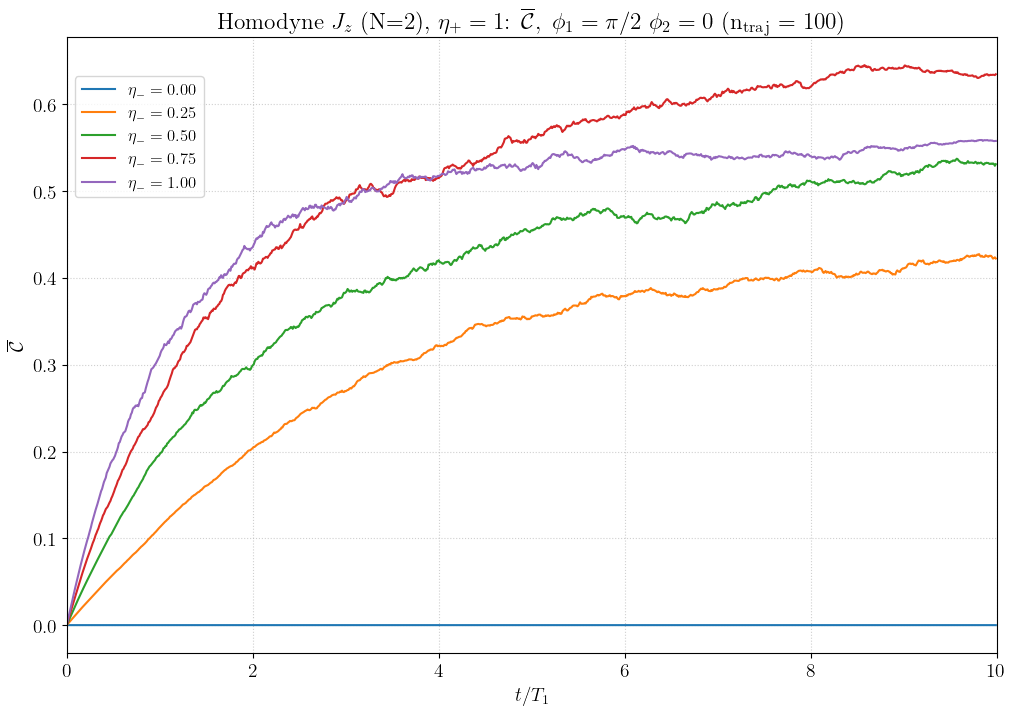

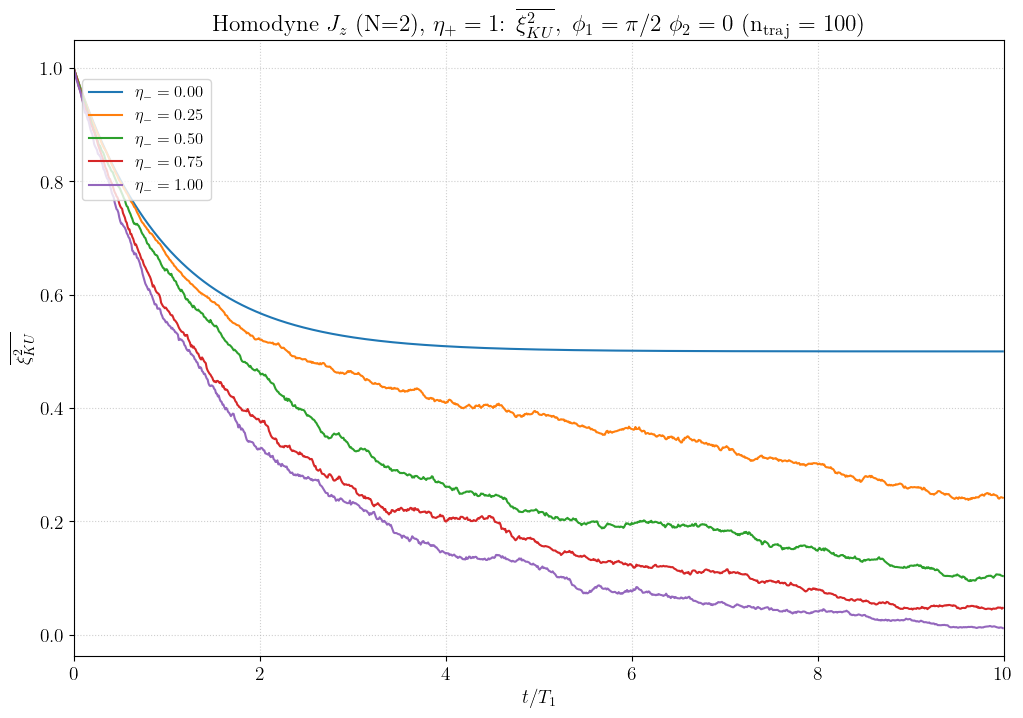

In [11]:
# PLOT + SAVE PDF
phi1_tex = angle_to_tex(float(phi1))
phi2_tex = angle_to_tex(float(phi2))

x = times / T1

for col in columns:
    plt.figure(figsize=(12, 8))

    for eta_minus, label in zip(eta_minus_list, eta_minus_labels):
        y = ineff_df[label][col].to_numpy()
        plt.plot(x, y, label=rf"$\eta_- = {eta_minus:.2f}$")

    plt.xlim(0.0, float(t_end))
    plt.xlabel(r"$t/T_1$")
    plt.ylabel(LABELS[col])
    plt.title(
        r"Homodyne $J_z$ (N=2), $\eta_+=1$: "
        + LABELS[col]
        + rf"$,\ \phi_1={phi1_tex}\ \phi_2={phi2_tex}$"
        + rf"  (n$_\mathrm{{traj}}$ = {ntraj})"
    )
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper left", bbox_to_anchor=(0, 0.95), fontsize=12)
    plt.savefig(out_dir / f"Homodyne_eta_minus_scan_{col}.pdf", bbox_inches="tight")
    plt.show()


In [ ]:
# QUICK LOOK
ineff_df[eta_minus_labels[-1]].describe()
